<a href="https://colab.research.google.com/github/alfavinyl/Sismologico_Nacional_Analisis_de_datos/blob/main/Sismol%C3%B3gico_nacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problema**

México es uno de los países con mayor actividad sísmica del mundo. En este contexto, resulta fundamental considerar el comportamiento histórico de los sismos como un elemento clave en la toma de decisiones. Si bien se han desarrollado diversas estrategias en materia de infraestructura, urbanismo y protección civil, aún existe margen para fortalecer la incorporación de análisis sistemáticos de datos sísmicos en estos ámbitos. El aprovechamiento de la información generada por el Servicio Sismológico Nacional puede contribuir a una mejor comprensión del riesgo sísmico y, en consecuencia, a la implementación de medidas más informadas y efectivas.

**Datos**

* Fuente: Catálogo del Servicio Sismológico Nacional (SSN-UNAM)
* Período: 1925 – 2023 (100 años de registros)
* Registros: ~287,000 sismos
* Variables principales: fecha, magnitud, profundidad, localización geográfica

**Preguntas que guían el análisis**

*   ¿Cómo ha evolucionado la actividad sísmica en México a lo largo de 100 años?
*   ¿Qué zonas concentran los sismos más peligrosos?
*   ¿Existe alguna relación entre profundidad y magnitud?
*   ¿En qué épocas del año ocurren más sismos?



In [1]:
import pandas as pd
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("johnr0s/ssn-unam-sismos-1925-2023")

full_path = os.path.join(path, "SSNMX_catalogo_19230101_20230922.csv")
print("Path to dataset files:", path)

archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

df_sismos = pd.read_csv(full_path)


100%|██████████| 6.84M/6.84M [00:00<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/johnr0s/ssn-unam-sismos-1925-2023/versions/1
Archivos en la carpeta: ['SSNMX_catalogo_19230101_20230922.csv']


/tmp/ipykernel_1883/2721172755.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sismos = pd.read_csv(full_path)


In [3]:
# Conversion de valores object a int y floats
# Convertir Magnitud y Profundidad a float
df_sismos['Magnitud'] = pd.to_numeric(df_sismos['Magnitud'], errors='coerce')
df_sismos['Profundidad'] = pd.to_numeric(df_sismos['Profundidad'], errors='coerce')
df_sismos['Fecha local'] = pd.to_datetime(df_sismos['Fecha local'], errors='coerce')

#.shape nos devuelve una tupla de (filas, columnas)
print(f'Filas: {df_sismos.shape[0]} | Columnas: {df_sismos.shape[1]}')

df_sismos.info()

Filas: 288206 | Columnas: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288206 entries, 0 to 288205
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Fecha UTC                   288206 non-null  object        
 1   Hora UTC                    288206 non-null  object        
 2   Magnitud                    270557 non-null  float64       
 3   Latitud                     288206 non-null  float64       
 4   Longitud                    288206 non-null  float64       
 5   Profundidad                 288136 non-null  float64       
 6   Referencia de localizacion  288206 non-null  object        
 7   Fecha local                 113352 non-null  datetime64[ns]
 8   Hora local                  288206 non-null  object        
 9   Estatus                     288206 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 22.0+ MB


# FASE 1: LIMPIEZA Y EXPLORACIÓN INICIAL

In [8]:
#1. ¿Cuántos valores nulos hay por columna?

#Para magnitud tenemos 17649 valores nulos, lo que equivale al 6.1% de datos nulos
#Para Profundidad 70 valores nulos, lo que equivale al 0.2% de datos nulos

total_nulos = df_sismos.isnull().sum()
total_filas = len(df_sismos)
nulos_magnitud = df_sismos['Magnitud'].isnull().sum()
porcentaje_nulo_mag = nulos_magnitud/total_filas * 100

nulos_profundidad = df_sismos['Profundidad'].isnull().sum()
porcentaje_nulo_prof = nulos_profundidad/total_filas * 100

print(total_nulos)
print(f'El porcentaje de datos nulos en la columna Maginutd es: {porcentaje_nulo_mag.round(2)}')
print(f'El porcentaje de datos nulos en la columna Profundidad es: {porcentaje_nulo_prof.round(2)}')

Fecha UTC                          0
Hora UTC                           0
Magnitud                       17649
Latitud                            0
Longitud                           0
Profundidad                       70
Referencia de localizacion         0
Fecha local                   174854
Hora local                         0
Estatus                            0
dtype: int64
El porcentaje de datos nulos en la columna Maginutd es: 6.12
El porcentaje de datos nulos en la columna Profundidad es: 0.02


In [9]:
#2. ¿Cómo se ven las primeras y últimas 10 filas?

df_sismos.head(10)

,Fecha UTC,Hora UTC,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha local,Hora local,Estatus
0,07/08/1925,07:47:48,6.7,19.00,-102.00,100.0,"10 km al SURESTE de NUEVA ITALIA, MICH",1925-07-08,01:47:48,revisado
1,16/11/1925,11:54:54,7.0,18.00,-107.00,33.0,"291 km al SUROESTE de CIHUATLAN, JAL",NaT,05:54:54,revisado
2,10/12/1925,14:14:42,7.0,15.50,-92.50,33.0,"31 km al NOROESTE de MOTOZINTLA, CHIS",1925-10-12,08:14:42,revisado
3,10/02/1928,04:39:37,6.5,18.26,-97.99,84.0,"9 km al NORESTE de ACATLAN DE OSORIO, PUE",1928-09-02,22:39:37,revisado
4,22/03/1928,04:17:30,7.5,15.67,-96.10,33.0,"12 km al SURESTE de CRUCECITA, OAX",NaT,22:17:30,revisado
5,17/04/1928,03:25:27,6.7,17.69,-96.44,115.0,"55 km al SUROESTE de TUXTEPEC, OAX",NaT,21:25:27,revisado
6,17/06/1928,03:19:28,7.6,16.33,-96.70,33.0,"11 km al OESTE de MIAHUATLAN, OAX",NaT,21:19:28,revisado
7,04/08/1928,18:28:17,7.4,16.83,-97.61,33.0,"49 km al SUR de H TLAXIACO, OAX",1928-04-08,12:28:17,revisado
8,09/10/1928,03:01:08,7.5,16.30,-97.30,33.0,"35 km al NORESTE de RIO GRANDE, OAX",1928-08-10,21:01:08,revisado
9,02/01/1931,09:49:02,6.7,19.00,-107.00,33.0,"257 km al SUROESTE de PUERTO VALLARTA, JAL",1931-02-01,03:49:02,revisado


In [10]:
df_sismos.tail(10)

,Fecha UTC,Hora UTC,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha local,Hora local,Estatus
288196,22/09/2023,06:21:37,3.7,16.09,-98.98,16.9,"89 km al SURESTE de SAN MARCOS, GRO",NaT,00:21:37,verificado
288197,22/09/2023,06:43:05,3.6,18.88,-104.98,4.4,"59 km al SUROESTE de CIHUATLAN, JAL",NaT,00:43:05,verificado
288198,22/09/2023,07:07:05,3.6,18.65,-103.91,4.3,"29 km al SUR de TECOMAN, COL",NaT,01:07:05,verificado
288199,22/09/2023,07:11:59,3.7,18.00,-102.65,16.1,"34 km al OESTE de LA MIRA, MICH",NaT,01:11:59,verificado
288200,22/09/2023,08:36:12,3.9,18.05,-104.05,16.4,"97 km al SUR de TECOMAN, COL",NaT,02:36:12,verificado
288201,22/09/2023,08:38:19,3.1,19.37,-103.75,29.5,"12 km al NORTE de VILLA DE ALVAREZ, COL",NaT,02:38:19,verificado
288202,22/09/2023,10:18:24,3.6,18.69,-103.86,4.3,"24 km al SUR de TECOMAN, COL",NaT,04:18:24,verificado
288203,22/09/2023,10:22:49,3.6,30.95,-116.51,7.3,"56 km al NOROESTE de VICENTE GUERRERO, BC",NaT,04:22:49,verificado
288204,22/09/2023,10:50:17,4.0,15.03,-94.23,28.7,"127 km al SUROESTE de TONALA, CHIS",NaT,04:50:17,verificado
288205,22/09/2023,12:35:59,4.3,17.02,-100.89,7.7,"35 km al SUROESTE de TECPAN, GRO",NaT,06:35:59,verificado


In [11]:
#3. Genera un resumen estadístico solo de las columnas numéricas
df_sismos.describe()

,Magnitud,Latitud,Longitud,Profundidad,Fecha local
count,270557.000000,288206.000000,288206.000000,288136.000000,113352
mean,3.641628,17.741624,-98.888472,32.519065,2014-09-12 04:49:06.008892672
min,0.300000,10.271000,-120.595000,1.000000,1925-07-08 00:00:00
25%,3.400000,15.876500,-100.789000,10.000000,2014-11-08 00:00:00
50%,3.600000,16.480000,-98.019000,16.400000,2018-08-07 00:00:00
75%,3.800000,17.932500,-94.842000,38.200000,2021-02-11 00:00:00
max,8.200000,38.092300,-85.546700,338.000000,2023-12-09 00:00:00
std,0.401109,4.012953,5.645722,36.108350,NaN


In [17]:
#4. ¿Existen registros con profundidades negativas o cero? ¿Y magnitudes negativas?
#No existen valores negativos ni iguales a cero para Magnitud ni Profundidad

negativos = (df_sismos['Profundidad'] <= 0).sum()
print(f'La cantidad de registros con profundidades negativas o cero son: {negativos}')

La cantidad de registros con profundidades negativas o cero son: 0


In [19]:
#5. Normaliza los nombres de las columnas (Convierte todos los nombres de columnas a minúsculas y sin espacios )

for col in df_sismos.select_dtypes(include="object"):
  df_sismos[col] = df_sismos[col].str.lower().str.replace(' ', '_')

df_sismos.head()

,Fecha UTC,Hora UTC,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha local,Hora local,Estatus
0,07/08/1925,07:47:48,6.7,19.00,-102.00,100.0,"10_km_al_sureste_de_nueva_italia,_mich",1925-07-08,01:47:48,revisado
1,16/11/1925,11:54:54,7.0,18.00,-107.00,33.0,"291_km_al_suroeste_de_cihuatlan,_jal",NaT,05:54:54,revisado
2,10/12/1925,14:14:42,7.0,15.50,-92.50,33.0,"31_km_al_noroeste_de_motozintla,_chis",1925-10-12,08:14:42,revisado
3,10/02/1928,04:39:37,6.5,18.26,-97.99,84.0,"9_km_al_noreste_de_acatlan_de_osorio,_pue",1928-09-02,22:39:37,revisado
4,22/03/1928,04:17:30,7.5,15.67,-96.10,33.0,"12_km_al_sureste_de_crucecita,_oax",NaT,22:17:30,revisado


# FASE 2: ANÁLISIS UNIVARIADO

In [4]:
#6. ¿Cuál es la magnitud promedio, mediana, máxima y mínima de los sismos registrados?

#promedio
promedio_magnitud = df_sismos['Magnitud'].mean()
print("El promedio de la magnitud de los temblores en México es: ", promedio_magnitud.round(1))

#mediana
print("La mediana de la magnitud de temblores en México es: ", df_sismos['Magnitud'].median())

#máximo
print("La Magnitud máxima de un temblor en México es: ", df_sismos['Magnitud'].max())

#mínimo
print("El valor mínimo de la magnitud de un temblor es: ", df_sismos['Magnitud'].min())

# Cuenta total de filas en el DataFrame
total_temblores = len(df_sismos)
print(f"Total de registros en el catálogo: {total_temblores}")


El promedio de la magnitud de los temblores en México es:  3.6
La mediana de la magnitud de temblores en México es:  3.6
La Magnitud máxima de un temblor en México es:  8.2
El valor mínimo de la magnitud de un temblor es:  0.3
Total de registros en el catálogo: 288206


In [10]:
#7. ¿Cuál ha sido el sismo más profundo y el más superficial en la historia del catálogo?

profundidad_min = df_sismos['Profundidad'].min()
profundidad_max = df_sismos['Profundidad'].max()
#print(profundidad_max)
#print(profundidad_min)

# Paso 1: Encontrar el índice de la profundidad máxima
indice_max = df_sismos['Profundidad'].idxmax()
# Paso 2: Usar loc para ver toda la fila
sismo_mas_profundo =df_sismos.loc[indice_max]

print(f'El sismo más profundo ha sido: {sismo_mas_profundo['Profundidad']} km')

El sismo más profundo ha sido: 338.0 km


In [14]:
#8. ¿Cuál es el sismo más superficial (mínima profundidad)?

# Paso 1: Encontrar el índice de la profundidad mínima
indice_min = df_sismos['Profundidad'].idxmin()
# Paso 2: Usar loc para ver toda la fila
sismo_mas_superficial =df_sismos.loc[indice_min]

print(f'El sismo menos profundo ha sido de: {sismo_mas_superficial['Profundidad']} km')

El sismo menos profundo ha sido de: 1.0 km


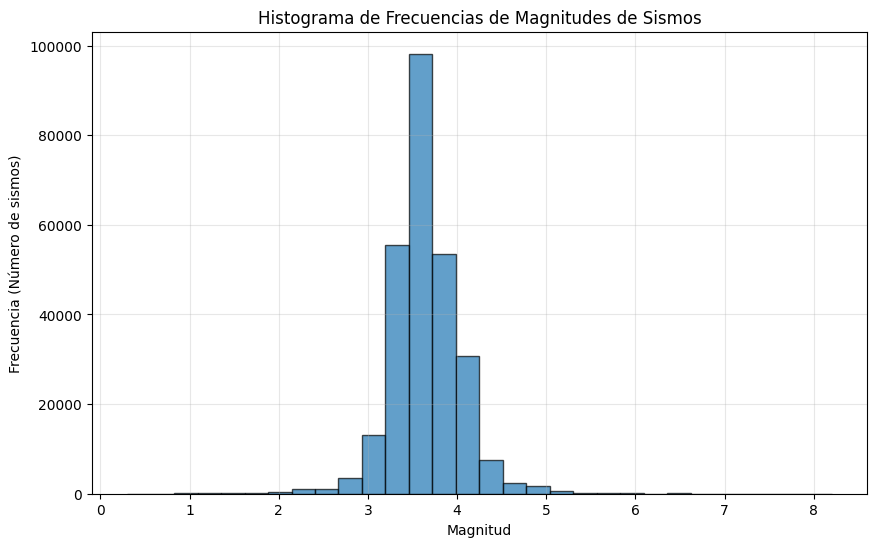

In [ ]:
#9. ¿Qué rango de profundidad concentra la mayor cantidad de sismos?

import matplotlib.pyplot as plt

# Línea 1: Esto crea un espacio en blanco donde se dibujará todo
plt.figure(figsize=(10, 6))

# Línea 2: Dibuja el histograma
# - df_sismos['Magnitud']: Selecciona la columna 'Magnitud' del DataFrame
# - .dropna(): Elimina los valores nulos (NaN) para no causar errores
# - bins=30: Divide los datos en 30 intervalos (barras) del mismo tamaño
# - edgecolor='black': Pone borde negro a cada barra del histograma
# - alpha=0.7: Hace las barras 70% opacas (0=transparente, 1=sólido)
plt.hist(df_sismos['Magnitud'].dropna(), bins=30, edgecolor='black', alpha=0.7)

# Línea 3: Etiqueta del eje X.
plt.xlabel('Magnitud')

# Línea 4: Etiqueta del eje Y.
plt.ylabel('Frecuencia (Número de sismos)')

# Línea 5: Título del gráfico
plt.title('Histograma de Frecuencias de Magnitudes de Sismos')

# Línea 6: Agrega una cuadrícula (rejilla) para facilitar la lectura
# - True: Activa la cuadrícula
# - alpha=0.3: Hace las líneas de la cuadrícula 30% opacas (suaves, que no molesten)
# - La cuadrícula ayuda a leer mejor los valores de las barras
plt.grid(True, alpha=0.3)

plt.show()

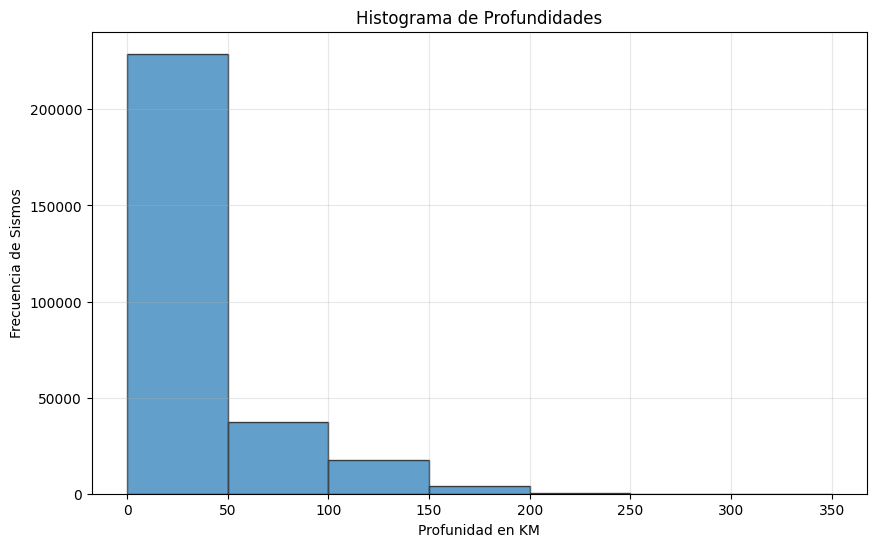

In [ ]:
#10. Crea un histograma de profundidades. Usa bins razonables (ej: 0-50, 50-100, etc.)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bins_profundidades = [0, 50, 100, 150, 200, 250, 300, 350]

plt.hist(df_sismos['Profundidad'].dropna(), bins=bins_profundidades, edgecolor='black', alpha=0.7)

plt.xlabel('Profunidad en KM')

plt.ylabel('Frecuencia de Sismos')

plt.title('Histograma de Profundidades')

plt.grid(True, alpha=0.3)

plt.show()


#0-50 km    ████████████████████  → Corteza terrestre (mayoría de sismos)
#50-100 km  ████████              → Menos sismos
#100-150 km ████                  → Aún menos
#150-200 km ██                    → Muy pocos
#200-300 km █                     → Excepcionales
#300+ km    ▏                     → Extremadamente raros


# FASE 3: FILTRADO Y CONDICIONES

In [17]:
#11. ¿Cuántos sismos han tenido magnitud ≥ 6?
conteo = len(df_sismos[df_sismos['Magnitud'] >= 6])
print(f'La cantidad de sismos que han tenido una magnitud mayor a 6 fueron: {conteo}')

La cantidad de sismos que han tenido una magnitud mayor a 6 fueron: 278


In [4]:
#12. Muestra solo los sismos con magnitud ≥ 7 Y profundidad < 50 km
muestra1 = df_sismos[(df_sismos['Magnitud'] >= 7) & (df_sismos['Profundidad'] < 50)]
print(f'En el histórico los sismos que han tenido una magnitud mayor de 7 y una profundidad menor a 50 km fueron: {len(muestra1)}')

En el histórico los sismos que han tenido una magnitud mayor de 7 y una profundidad menor a 50 km fueron: 53


In [5]:
#13. ¿Cuántos sismos ocurrieron con magnitud entre 4 y 5?
conteo2 = len(df_sismos[(df_sismos['Magnitud'] >= 4) & (df_sismos['Magnitud'] <= 5)])

print(f'La cantidad de sismos con magnitud ocurridos con una magnitud entre 4 y 5 es: {conteo2}')

La cantidad de sismos con magnitud ocurridos con una magnitud entre 4 y 5 es: 42338


In [8]:
#14. Muestra solo las columnas fecha_local, magnitud, profundidad para los 10 sismos más recientes

#Primero ordena por fecha, luego selecciona columnas con corchetes dobles

# Convertir columna de fecha a datetime
df_sismos['Fecha local'] = pd.to_datetime(df_sismos['Fecha local'], errors='coerce')

# Ordenar de más reciente a más antigua (descendente)
df_sismos_ordenado = df_sismos.sort_values('Fecha local', ascending=False)

#print(df_sismos_ordenado)
print('Estas son las columnas fecha_local, magnitud, profundidad para los 10 sismos más recientes hasta el año 2023')
df_sismos_ordenado[['Fecha local','Magnitud', 'Profundidad']].head(10)


Estas son las columnas fecha_local, magnitud, profundidad para los 10 sismos más recientes hasta el año 2023


,Fecha local,Magnitud,Profundidad
287580,2023-12-09,3.3,3.1
287537,2023-12-09,3.3,29.7
287531,2023-12-09,4.0,70.4
287532,2023-12-09,4.0,14.9
287533,2023-12-09,3.6,10.0
287534,2023-12-09,3.3,2.2
287535,2023-12-09,2.9,10.0
287536,2023-12-09,3.5,40.0
287538,2023-12-09,4.0,10.0
287528,2023-12-09,3.8,98.6


# FASE 4: AGRUPACIONES (GROUPBY)

In [11]:
#15. Agrupa por estatus y cuenta cuántos sismos hay en cada categoría
#df.groupby('estatus').size() o .count()
estatus = df_sismos.groupby('Estatus').size()
print('Tenemos dos estatus, Revisado y Verififcado, estos son los resultados para cada uno:')
print(estatus)

Tenemos dos estatus, Revisado y Verififcado, estos son los resultados para cada uno:
Estatus
revisado      276988
verificado     11218
dtype: int64


In [13]:
#16. Por cada rango de magnitud (crea una columna categórica), calcula la profundidad promedio

#Usa pd.cut() para crear rangos (ej: "bajo", "medio", "alto")

#Luego groupby().agg({'profundidad': ['mean', 'min', 'max']})

# Rangos de magnitud según escala Richter
bins_magnitud = [0,4,7,10]
etiquetas_magnitud = ['Bajo (<=4)', 'Medio (4-7)', 'alto (>7)']
df_sismos['categoria_magnitud'] = pd.cut(df_sismos['Magnitud'],
                                        bins=bins_magnitud,
                                        labels=etiquetas_magnitud)
analisis = df_sismos.groupby('categoria_magnitud').agg({
    'Profundidad': ['mean', 'min', 'max'],
    })

print(analisis)

                   Profundidad            
                          mean  min    max
categoria_magnitud                        
Bajo (<=4)           31.562250  1.0  287.0
Medio (4-7)          39.289794  1.0  338.0
alto (>7)            34.444231  9.0  160.0


/tmp/ipykernel_1883/4021259154.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analisis = df_sismos.groupby('categoria_magnitud').agg({


In [15]:
#17. Resumen de magnitud mínima, máxima y promedio por año

#Extrae el año de fecha_local

#Usa groupby('año')['magnitud'].agg(['min', 'max', 'mean'])

#Convertir fecha a datetime
df_sismos['Fecha local'] = pd.to_datetime(df_sismos['Fecha local'], errors='coerce')
#df_sismos.info()
# Extraer el año
df_sismos['año'] = df_sismos['Fecha local'].dt.year
#Usa groupby('año')['magnitud'].agg(['min', 'max', 'mean'])
resumen = df_sismos.groupby('año')['Magnitud'].agg(
    ['min', 'max','mean']
    )
print('A continuación se presenta solo un resumen del promedio, mínimo y máximo de la magnitud del historicos de sismos')
print(resumen)



A continuación se presenta solo un resumen del promedio, mínimo y máximo de la magnitud del historicos de sismos
        min  max      mean
año                       
1925.0  6.7  7.0  6.850000
1928.0  6.5  7.5  7.133333
1931.0  6.7  6.7  6.700000
1932.0  6.7  8.2  7.100000
1933.0  6.6  6.9  6.750000
...     ...  ...       ...
2019.0  1.0  6.5  3.609204
2020.0  0.6  6.0  3.600017
2021.0  0.6  7.1  3.550756
2022.0  0.6  6.3  3.532986
2023.0  0.6  5.8  3.562649

[75 rows x 3 columns]


# FASE 5: VISUALIZACIONES

año
1925.0        2
1928.0        3
1931.0        1
1932.0        4
1933.0        2
          ...  
2019.0    10496
2020.0    11908
2021.0    11709
2022.0    11523
2023.0     6953
Length: 75, dtype: int64


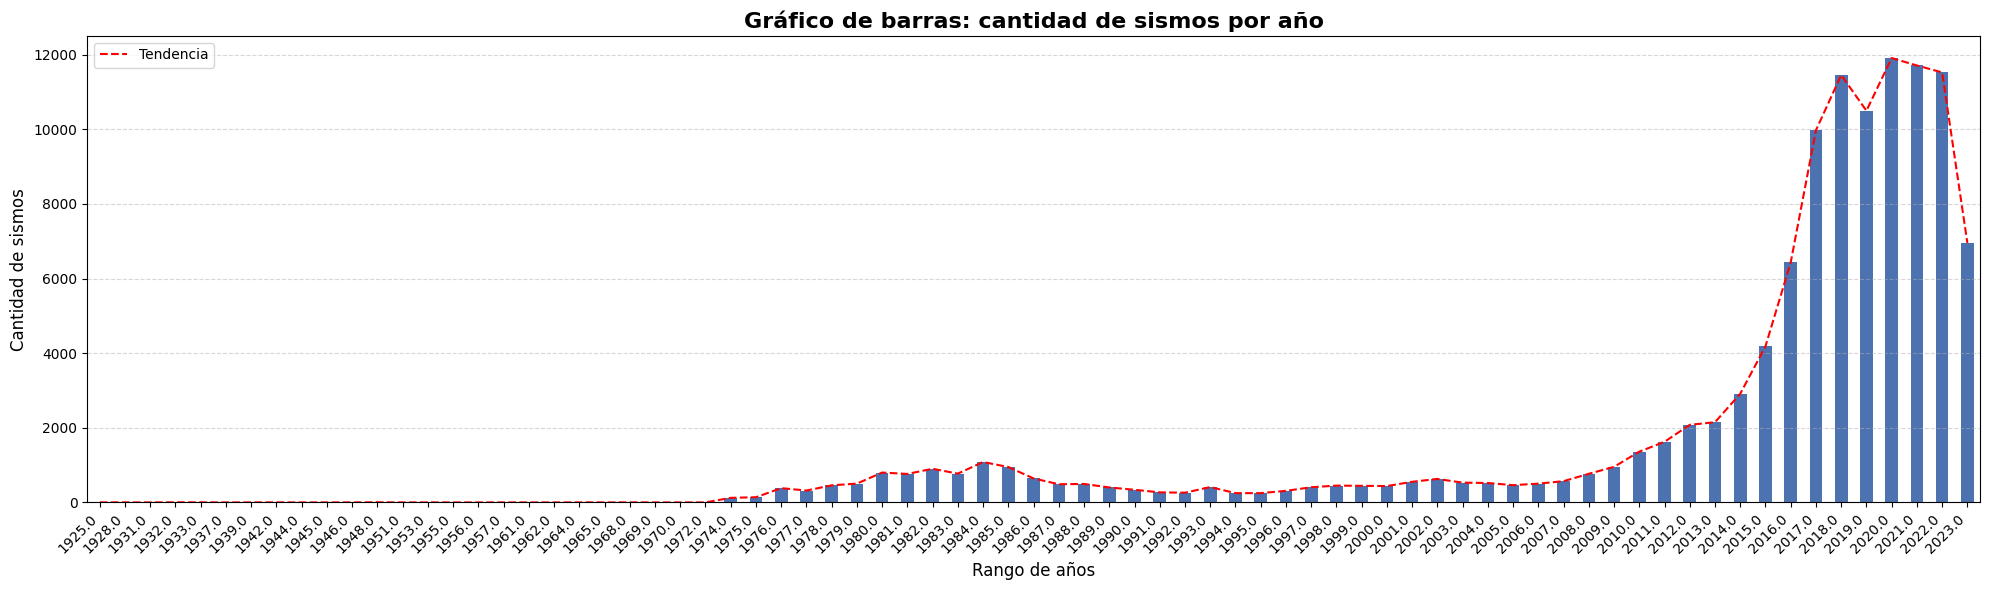

In [ ]:
#18. Gráfico de barras: cantidad de sismos por año
#Muestra tendencia temporal

#Convertir fecha a datetime
df_sismos['Fecha local'] = pd.to_datetime(df_sismos['Fecha local'], errors='coerce')
#df_sismos.info()
# Extraer el año
df_sismos['año'] = df_sismos['Fecha local'].dt.year
#Usa groupby('año')['magnitud'].agg(['min', 'max', 'mean'])
sismoporaño = df_sismos.groupby('año').size()
print(sismoporaño )

#comienza a graficar
import matplotlib.pyplot as plt
fig , ax = plt.subplots(figsize = (20,6)) #figura en blanco con tamaño 10,6

sismoporaño.plot(
    kind='bar',
    ax=ax,
    rot=0,
    color = '#4C72B0')

ax.plot(range(len(sismoporaño)), sismoporaño.values,
        color='red', linewidth=1.5, linestyle='--', label='Tendencia')
ax.legend()

#personalizar
ax.set_title('Gráfico de barras: cantidad de sismos por año', fontsize=16, fontweight='bold')
ax.set_ylabel('Cantidad de sismos', fontsize=12)
ax.set_xlabel('Rango de años', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

#ax.legend(title='Métrica', labels=['Mínimo', 'Máximo', 'Promedio'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



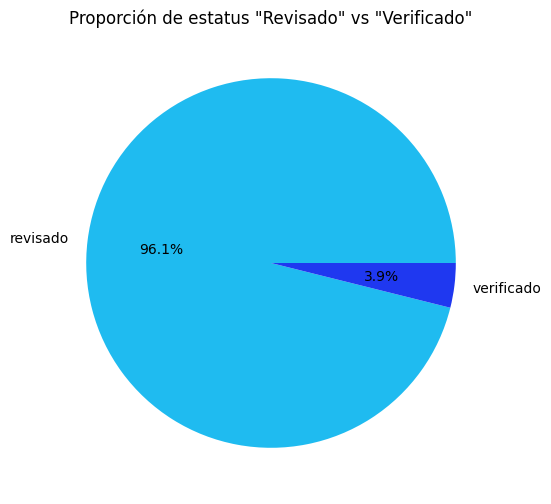

In [ ]:
#19. Gráfico de pastel: proporción de estatus

#Ej: "Automático" vs "Revisado"

#p.15 Agrupa por estatus y cuenta cuántos sismos hay en cada categoría
#df.groupby('estatus').size() o .count()
proporcion_estatus = df_sismos.groupby('Estatus').size()

import matplotlib.pyplot as plt
colores_pastel = [ '#1FBBF0', '#1F38F0','#1F7AF0', '#1FF0E1', '#A793F5', '#68A3F0']

proporcion_estatus.plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    colors = colores_pastel,
    figsize=(10,6),
    subplots=True
)

plt.title('Proporción de estatus "Revisado" vs "Verificado"')
plt.ylabel('')
plt.show()



Esta gráfica nos indica que los sismos de magnitud muy baja y muy alta se ha dado mayomernte a menor profundadad, en tanto los sismos con una magnitud entre 3 y 5 se generan a una profundad mayor


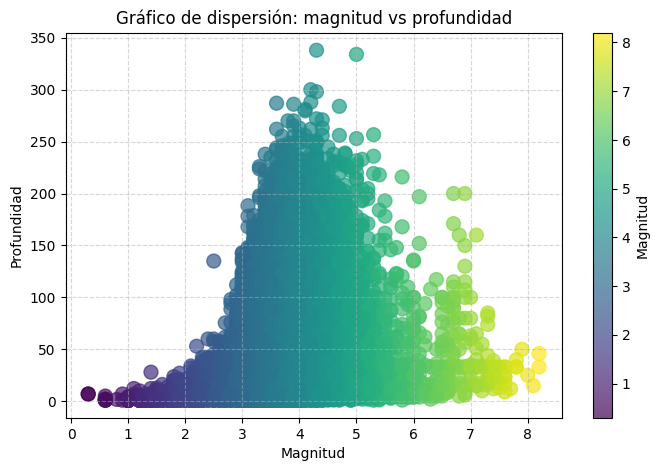

In [16]:
#20. Gráfico de dispersión: magnitud vs profundidad
#Color por rango de magnitud o estatus
import matplotlib.pyplot as plt
colores_dispersion = [ '#F02B1F', '#F0741F','#F0501F', '#F01F73', '#F5CC93', '#F04714']

df_sismos.plot(
    kind = 'scatter',
    x = 'Magnitud',
    y = 'Profundidad',
    c = 'Magnitud',  # ← Usa valores de magnitud para definir colores
    colormap = 'viridis',  # ← Mapa de colores (viridis, plasma, coolwarm, etc.)
    s=100, #size -> tamaño de los puntos
    alpha=0.7, #porcentaje de transparente
    figsize=(8, 5)
)

plt.title('Gráfico de dispersión: magnitud vs profundidad')
plt.grid(True, linestyle='--', alpha=0.5)
print('Esta gráfica nos indica que los sismos de magnitud muy baja y muy alta se ha dado mayomernte a menor profundadad, en tanto los sismos con una magnitud entre 3 y 5 se generan a una profundad mayor')
plt.show()




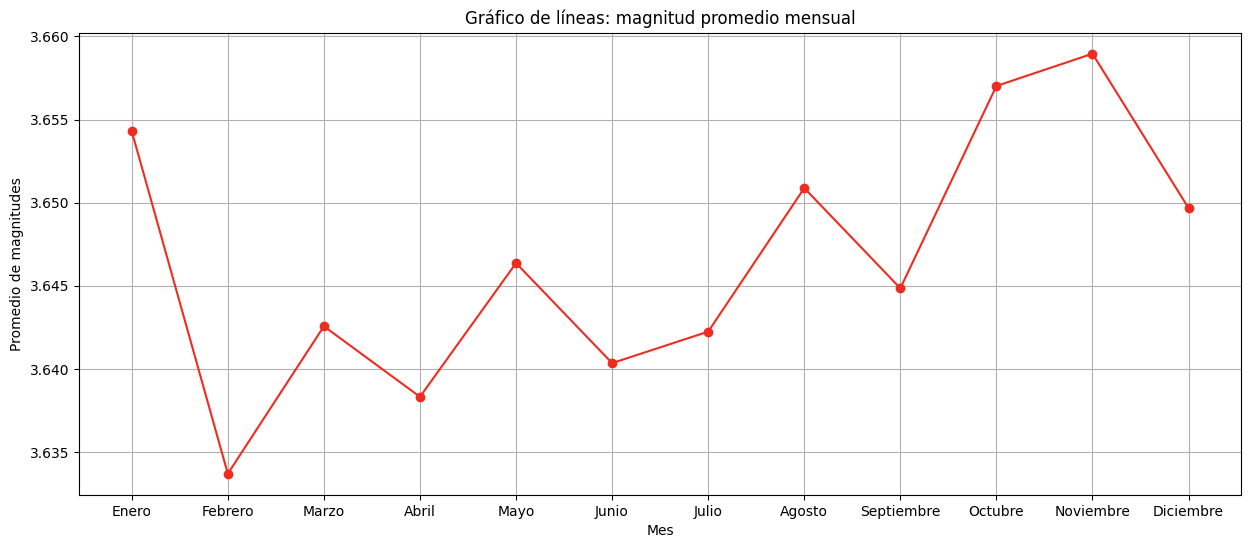

In [18]:
#21. Gráfico de líneas: magnitud promedio mensual

#Agrupa por mes y calcula promedio, luego línea temporal

#Convertir fecha a datetime
df_sismos['Fecha local'] = pd.to_datetime(df_sismos['Fecha local'], errors='coerce')
#df_sismos.info()
# Extraer el año
df_sismos['mes'] = df_sismos['Fecha local'].dt.month
#Usa groupby('año')['magnitud'].agg(['min', 'max', 'mean'])
sismopormes = df_sismos.groupby('mes')['Magnitud'].mean()
promediopormes = sismopormes.mean()
#print(sismopormes )
#print(promediopormes)
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

#GRAFICAR
plt.figure(figsize=(15, 6))
sismopormes.plot(kind='line',
                 marker='o',
                 color='#F02B1F',
                 xlabel = 'Mes',
                 ylabel = 'Promedio de magnitudes',
                 grid = True

                 )
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], meses)
plt.title("Gráfico de líneas: magnitud promedio mensual") #Añade título
plt.show() #Mostrar la gráfica



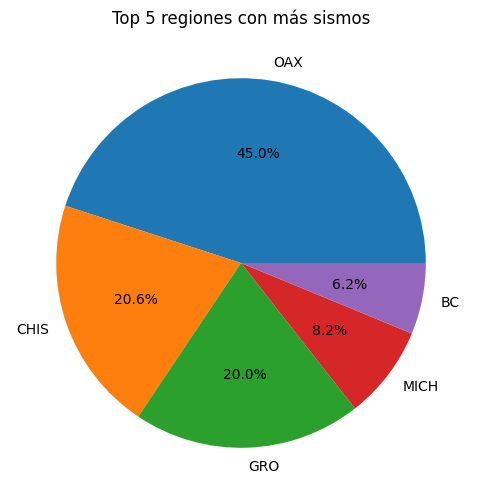

In [20]:
#22. Gráfico de pastel (alternativo): top 5 regiones con más sismos

#Extrae estado de la referencia_de_localizacion (puedes hacerlo con .str.split())
# Paso 1: Dividir por coma
partes = df_sismos['Referencia de localizacion'].str.split(',')

# Paso 2: Tomar la parte del estado (segunda parte)
estado_sucio = partes.str[1]

# Paso 3: Limpiar espacios
estado_limpio = estado_sucio.str.strip()
#print(estado_limpio)
# Contar sismos por región
sismos_por_estado = df_sismos.groupby(estado_limpio).size().sort_values(ascending=False)
#print(sismos_por_estado.head())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (10,6)) #figura en blanco con tamaño 10,6

colores = ['#FA57C0', '#FA7257', '#FA575F', '#E256F9', '#FA8E57']


sismos_por_estado.head().plot(
 kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    fontsize=10,
    color = colores
 )

#personificar
plt.title('Top 5 regiones con más sismos')
plt.ylabel('')
plt.show()



# FASE 6 (MAPA DE CALOR)

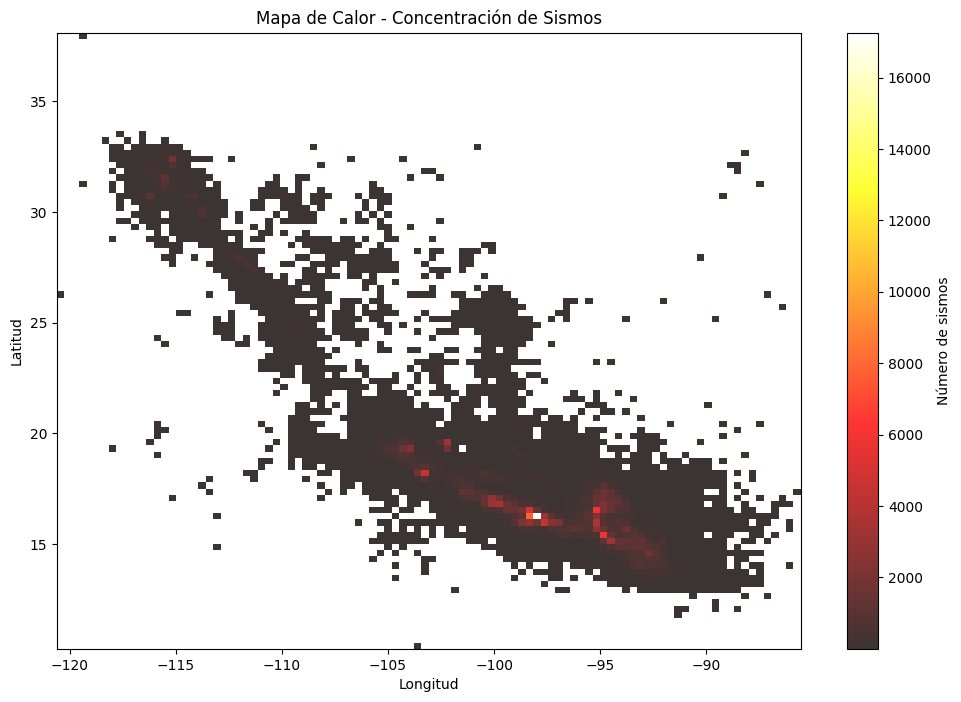

In [ ]:
#23. Mapa de calor de densidad sísmica
#Usa plt.hist2d o seaborn.kdeplot con latitud y longitud
#¿Cuál es la referencia de localización con mayor cantidad de sismos?

#value_counts().head(10)

import matplotlib.pyplot as plt

# Crear la figura y los ejes
plt.figure(figsize=(12, 8))

# Crear el mapa de calor 2D (histograma en 2 dimensiones)
# x = longitud, y = latitud
hist = plt.hist2d(
    df_sismos['Longitud'],           # Eje X (longitud)
    df_sismos['Latitud'],            # Eje Y (latitud)
    bins=100,                        # Número de celdas (100x100)
    cmap='hot',                      # Mapa de colores ('hot', 'viridis', 'plasma')
    alpha=0.8,                       # Transparencia
    cmin=1                           # Mínimo de sismos para mostrar color
)

# Agregar barra de colores (muestra la escala)
plt.colorbar(label='Número de sismos')

# Etiquetas
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Mapa de Calor - Concentración de Sismos')

# Mostrar el gráfico
plt.show()



# Conclusiones y Hallazgos

## Hallazgos principales

1. **Actividad sísmica creciente:** El catálogo registra 288206 sismos en cerca de 100 años.
   La actividad ha aumentado notablemente a partir de 2015, posiblemente
   relacionado con mejoras en la capacidad de detección del SSN.

2. **La mayoría de los sismos son de baja magnitud:** El promedio de magnitud
   es de 3.6, y el 78.72% de los sismos registrados se encuentran por debajo de
   magnitud 4, lo que los hace imperceptibles para la población.

3. **Zonas de mayor riesgo:** Las regiones con mayor concentración sísmica son
   Oaxaca, Chiapas, Guerrero, lo que coincide con las principales
   placas tectónicas que atraviesan el territorio mexicano.

4. **Profundidad y riesgo:** El 79.43% de los sismos ocurre a menos de 50 km de
   profundidad. Los sismos superficiales son generalmente más destructivos
   porque liberan su energía más cerca de la superficie.

5. **Sismos extremos:** Solo 52 sismos en 100 años han superado magnitud 7,
   lo que representa el 0.01% del catálogo. Sin embargo, estos eventos
   concentran el mayor potencial destructivo.

## Propuestas basadas en el análisis

**1. Reforzar los sistemas de alerta temprana en las zonas de mayor concentración sísmica**
El 85.6% de los sismos registrados entre 1925 y 2023 se concentra en Guerrero, Oaxaca
y Chiapas. Esta concentración sugiere que los recursos de monitoreo, alerta temprana
y respuesta de emergencia deberían priorizarse en estas entidades, garantizando que
su infraestructura de protección civil esté a la altura del riesgo real que enfrentan.

**2. Revisar los códigos de construcción en regiones de sismicidad superficial**
El 75.81% de los sismos ocurre a menos de 40 km de profundidad. Los sismos
superficiales liberan su energía más cerca de la superficie, lo que los hace
potencialmente más destructivos. Esto representa un argumento sólido para revisar
y actualizar los estándares de construcción en las zonas de mayor actividad,
especialmente en zonas urbanas de Guerrero, Oaxaca y Chiapas.

**3. Comunicar el aumento en el registro sísmico de forma transparente a la población**
A partir de 2015 se observa un incremento significativo en el número de sismos
registrados. Es importante que instituciones como el SSN comuniquen claramente
que este aumento refleja en parte mejoras en la capacidad de detección tecnológica,
y no necesariamente un incremento real en la actividad sísmica. Una comunicación
transparente evita el pánico innecesario y fortalece la confianza pública en las
instituciones científicas.